<a href="https://colab.research.google.com/github/qichinnn/FundamentalAI_2026A/blob/main/Q4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A。

## Problem Statement: Predicting Food Demand for CompanyA's Hari Raya Initiative

**CompanyA**, a charity organization, aims to provide lunchboxes to **40 families for 30 days** during the upcoming Hari Raya celebration. The core challenge is to accurately predict the daily food demand to ensure:

1.  **Minimizing Waste**: Over-preparation leads to food waste, which is costly and goes against the charity's mission.
2.  **Ensuring Sufficiency**: Under-preparation means some families might not receive adequate food, failing to meet their needs.
3.  **Efficient Resource Allocation**: Optimizing the use of ingredients, cooking staff, volunteers, and logistics.

This task is complex due to various factors that influence demand, such as family size variations, dietary restrictions, potential fluctuations in attendance, and the dynamic nature of a festive period. A precise prediction system is crucial for the success and sustainability of this benevolent initiative.

## Why AI is Suitable for Food Demand Prediction

AI (Artificial Intelligence) is exceptionally well-suited for solving complex prediction problems like food demand forecasting for several compelling reasons:

1.  **Handling Complexity and Multiple Variables**: Food demand is influenced by numerous factors, including:
    *   **Historical Data**: Past demand during similar events or periods.
    *   **Demographics**: Family size, age groups, and specific needs of the 40 families.
    *   **Calendar Events**: The specific days of Hari Raya, public holidays, or other community events.
    *   **External Factors**: Weather conditions, economic indicators, or local news.
    AI models can process and learn from these diverse, interconnected variables simultaneously, identifying subtle patterns that humans might overlook.

2.  **Pattern Recognition**: AI algorithms, especially machine learning models, excel at identifying non-linear relationships and hidden patterns within large datasets. For instance, they can detect how demand shifts based on the day of the week during a festive period, or how certain family profiles correlate with higher or lower consumption.

3.  **Data-Driven Decision Making**: Instead of relying on intuition or simple averages, AI provides data-backed predictions. This leads to more accurate forecasts, reducing both waste and shortages.

4.  **Optimization**: Beyond prediction, AI can be integrated into optimization systems to recommend ideal quantities for ingredient procurement, cooking schedules, and delivery routes, leading to significant cost savings and operational efficiency for CompanyA.

5.  **Adaptability and Continuous Improvement**: As new data becomes available (e.g., actual consumption during the first few days, feedback from families), AI models can be retrained and refined. This allows the system to continuously learn and improve its prediction accuracy over time, making future initiatives even more efficient.

By leveraging AI, CompanyA can move from reactive planning to proactive, intelligent forecasting, maximizing the impact of their charitable efforts while minimizing resource wastage.

b

### 1. Generating Dummy Dataset

In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta

# Set a random seed for reproducibility
np.random.seed(42)

# Define parameters for the dataset
start_date = pd.to_datetime('2023-01-01')
num_past_days = 90 # Historical data for 90 days

# Generate dates
dates = [start_date + timedelta(days=i) for i in range(num_past_days)]

# Generate dummy lunchboxes_delivered data
# Assume average demand around 150-250 lunchboxes, with some variation
lunchboxes_delivered = np.random.randint(150, 250, size=num_past_days)

# Introduce some 'holiday' effect for demonstration (e.g., higher demand on certain days)
# Let's say every 7th day is a 'weekend' or 'special event' with slightly higher demand
for i in range(num_past_days):
    if dates[i].dayofweek >= 5: # Saturday (5) or Sunday (6)
        lunchboxes_delivered[i] = int(lunchboxes_delivered[i] * 1.1) # 10% higher on weekends

# Generate dummy is_holiday column (binary: 0 for not holiday, 1 for holiday)
# Let's mark specific dates as holidays randomly for demonstration
holiday_indices = np.random.choice(num_past_days, size=num_past_days // 10, replace=False)
is_holiday = np.zeros(num_past_days, dtype=int)
is_holiday[holiday_indices] = 1

# Create DataFrame
df_historical = pd.DataFrame({
    'date': dates,
    'is_holiday': is_holiday,
    'lunchboxes_delivered': lunchboxes_delivered
})

display(df_historical.head())
display(df_historical.tail())


,date,is_holiday,lunchboxes_delivered
0,2023-01-01,0,221
1,2023-01-02,1,242
2,2023-01-03,0,164
3,2023-01-04,0,221
4,2023-01-05,0,210


,date,is_holiday,lunchboxes_delivered
85,2023-03-27,0,249
86,2023-03-28,0,163
87,2023-03-29,0,244
88,2023-03-30,0,197
89,2023-03-31,0,164


### 2. Prepare Data and Train Random Forest Regressor

To prepare the data, we'll extract numerical features from the 'date' column such as day of the week, day of the month, and month. These features, along with 'is_holiday', will be used to train the Random Forest Regressor.

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Feature engineering for historical data
df_historical['day_of_week'] = df_historical['date'].dt.dayofweek
df_historical['day_of_month'] = df_historical['date'].dt.day
df_historical['month'] = df_historical['date'].dt.month

# Define features (X) and target (y)
X = df_historical[['day_of_week', 'day_of_month', 'month', 'is_holiday']]
y = df_historical['lunchboxes_delivered']

# Split data into training and testing sets (optional, but good practice)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model (optional)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error on test set: {mae:.2f}")


Mean Absolute Error on test set: 24.43


### 3. Predict Demand for the Next 30 Days and Plot

Now, we'll generate the dates for the next 30 days, including Hari Raya, create corresponding features, predict the demand using our trained model, and visualize the results.

,date,day_of_week,day_of_month,month,is_holiday,predicted_lunchboxes
0,2023-04-01,5,1,4,1,222
1,2023-04-02,6,2,4,1,222
2,2023-04-03,0,3,4,1,191
3,2023-04-04,1,4,4,1,192
4,2023-04-05,2,5,4,1,202


,date,day_of_week,day_of_month,month,is_holiday,predicted_lunchboxes
25,2023-04-26,2,26,4,0,230
26,2023-04-27,3,27,4,0,219
27,2023-04-28,4,28,4,0,192
28,2023-04-29,5,29,4,0,215
29,2023-04-30,6,30,4,0,213


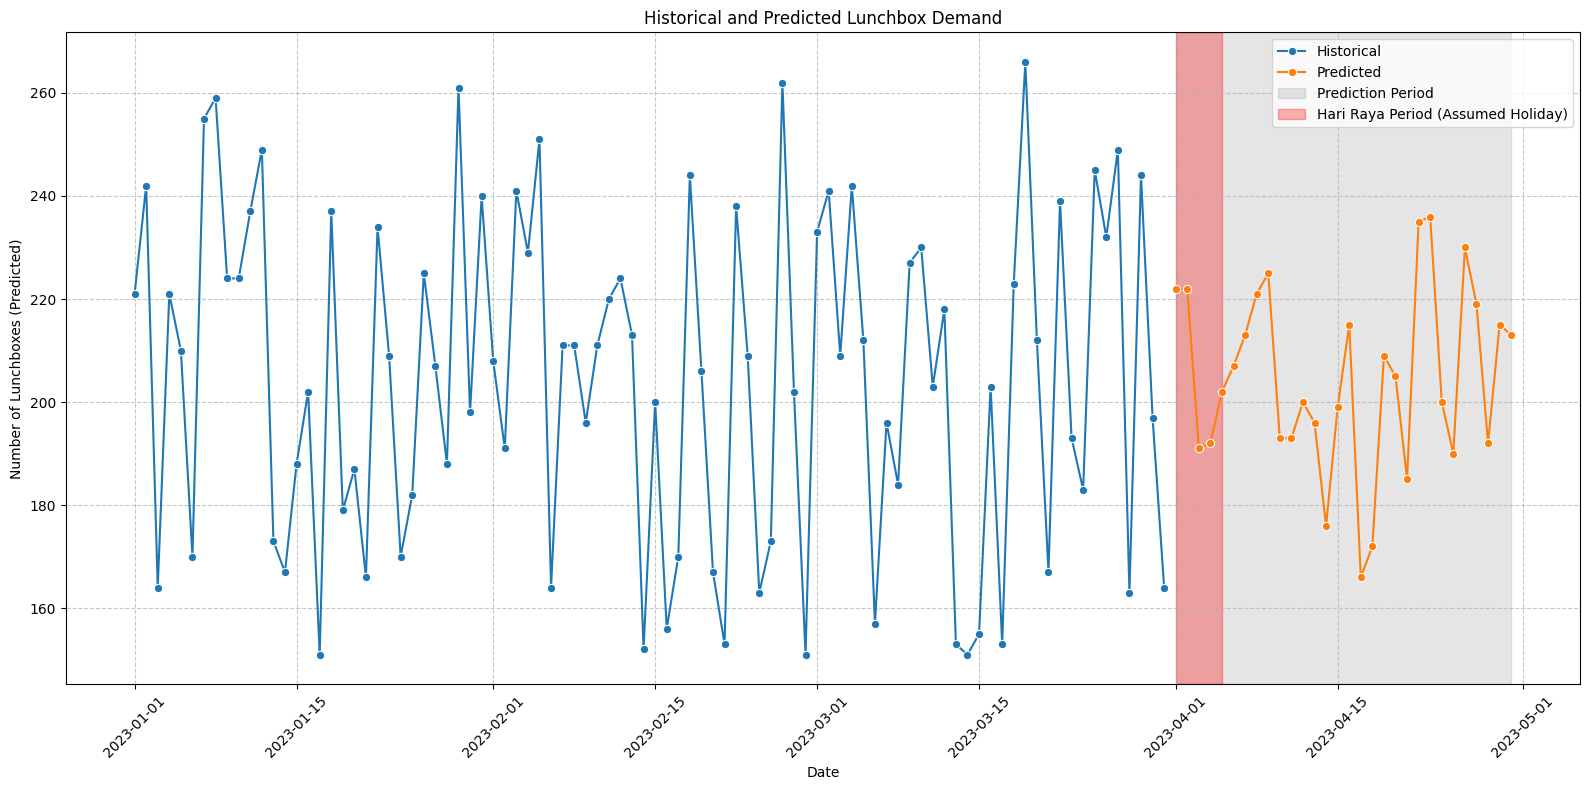

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define prediction period (next 30 days after historical data ends)
prediction_start_date = df_historical['date'].max() + timedelta(days=1)
num_prediction_days = 30
prediction_dates = [prediction_start_date + timedelta(days=i) for i in range(num_prediction_days)]

# Hari Raya period assumption (e.g., first 5 days of the 30-day prediction period)
hari_raya_period_start = prediction_start_date
hari_raya_period_end = prediction_start_date + timedelta(days=4) # Assuming 5 days of Hari Raya for increased demand

# Create DataFrame for future predictions
df_future = pd.DataFrame({
    'date': prediction_dates
})

# Feature engineering for future data (must match training features)
df_future['day_of_week'] = df_future['date'].dt.dayofweek
df_future['day_of_month'] = df_future['date'].dt.day
df_future['month'] = df_future['date'].dt.month

# Determine 'is_holiday' for future dates. Mark Hari Raya period as holiday (1) and other days as not (0).
df_future['is_holiday'] = df_future['date'].apply(lambda x: 1 if hari_raya_period_start <= x <= hari_raya_period_end else 0)

# Predict lunchbox demand for the next 30 days
future_predictions = model.predict(df_future[['day_of_week', 'day_of_month', 'month', 'is_holiday']])
df_future['predicted_lunchboxes'] = future_predictions.round().astype(int) # Round to nearest integer

display(df_future.head())
display(df_future.tail())

# Combine historical and predicted data for plotting
df_plot = pd.concat([
    df_historical.rename(columns={'lunchboxes_delivered': 'demand'}),
    df_future.rename(columns={'predicted_lunchboxes': 'demand'})
], ignore_index=True)

df_plot['type'] = ['Historical'] * len(df_historical) + ['Predicted'] * len(df_future)

# Plotting the historical and predicted demand
plt.figure(figsize=(16, 8))
sns.lineplot(x='date', y='demand', hue='type', data=df_plot, marker='o', errorbar=None)

# Highlight the prediction period
plt.axvspan(prediction_start_date, prediction_dates[-1], color='gray', alpha=0.2, label='Prediction Period')

# Highlight the Hari Raya period within the prediction
plt.axvspan(hari_raya_period_start, hari_raya_period_end, color='red', alpha=0.3, label='Hari Raya Period (Assumed Holiday)')

plt.title('Historical and Predicted Lunchbox Demand')
plt.xlabel('Date')
plt.ylabel('Number of Lunchboxes (Predicted)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


c

### Explanation of the Generated Code

The code I provided earlier is structured into three main sections, addressing your requirements for data generation, model training, and prediction visualization.

#### 1. Generating Dummy Dataset

This section focuses on creating a synthetic dataset that mimics historical lunchbox delivery data. This is crucial when real-world data might be unavailable or sensitive.

*   **Imports**: We start by importing necessary libraries: `pandas` for data manipulation, `numpy` for numerical operations (especially for random data generation), and `datetime`'s `timedelta` for date calculations.
*   **Reproducibility**: `np.random.seed(42)` ensures that every time you run this code, the 'random' numbers generated are the same, making your results consistent.
*   **Parameters**: `start_date` and `num_past_days` define the timeframe for our historical data (90 days starting from '2023-01-01').
*   **Date Generation**: A list of dates is created using `pd.to_datetime` and `timedelta` to cover the `num_past_days`.
*   **`lunchboxes_delivered` Data**: `np.random.randint(150, 250, size=num_past_days)` generates a base daily demand between 150 and 250 lunchboxes. A simple 'holiday' effect is then introduced: any day falling on a Saturday or Sunday has its demand increased by 10% to simulate higher festive or weekend demand.
*   **`is_holiday` Column**: `np.random.choice` is used to randomly select about 10% of the historical days and mark them as `is_holiday = 1`, while others are `0`. This creates a binary feature for the model.
*   **DataFrame Creation**: Finally, all this generated data (`date`, `is_holiday`, `lunchboxes_delivered`) is combined into a pandas DataFrame called `df_historical`. `display(df_historical.head())` and `display(df_historical.tail())` show the first and last few rows of this generated dataset, respectively.

#### 2. Prepare Data and Train Random Forest Regressor

This part handles the preparation of the historical data for machine learning and then trains a predictive model.

*   **Imports**: We import `RandomForestRegressor` (our chosen model), `train_test_split` for dividing data, and `mean_absolute_error` for evaluating the model.
*   **Feature Engineering**: New numerical features are extracted from the `date` column of `df_historical`: `day_of_week` (0=Monday, 6=Sunday), `day_of_month`, and `month`. These features help the model understand temporal patterns.
*   **Define Features (X) and Target (y)**: `X` (our input features) consists of `day_of_week`, `day_of_month`, `month`, and `is_holiday`. `y` (our target variable, what we want to predict) is `lunchboxes_delivered`.
*   **Train-Test Split**: `train_test_split(X, y, test_size=0.2, random_state=42)` divides the data into training (80%) and testing (20%) sets. The model learns from the training data and is evaluated on the unseen test data to assess its generalization ability.
*   **Model Initialization and Training**: `RandomForestRegressor(n_estimators=100, random_state=42)` creates a Random Forest model with 100 decision trees. The `model.fit(X_train, y_train)` line trains the model using the training features and target.
*   **Model Evaluation**: After training, `model.predict(X_test)` makes predictions on the test set. `mean_absolute_error(y_test, y_pred)` calculates the Mean Absolute Error (MAE), which tells us the average absolute difference between the actual and predicted lunchbox deliveries on the test set. A lower MAE indicates better accuracy.

#### 3. Predict Demand for the Next 30 Days and Plot

This final section uses the trained model to forecast future demand and then visualizes the results.

*   **Prediction Period Definition**: `prediction_start_date` is set to the day after the `df_historical` ends, and `num_prediction_days` is set to 30. `prediction_dates` are generated for this future period.
*   **Hari Raya Period Assumption**: A Hari Raya period is defined (e.g., the first 5 days of the prediction period). This is a crucial assumption to simulate the festive season's impact on demand.
*   **Future DataFrame (`df_future`)**: A new DataFrame `df_future` is created with the `prediction_dates`. Similar feature engineering (extracting `day_of_week`, `day_of_month`, `month`) is performed here, *matching the features used during training*.
*   **Future `is_holiday`**: The `is_holiday` column for `df_future` is populated, marking the Hari Raya period days as `1` and other days as `0`.
*   **Making Predictions**: `model.predict(df_future[['day_of_week', 'day_of_month', 'month', 'is_holiday']])` uses the trained model to forecast lunchbox demand for each day in the `df_future` DataFrame. The results are rounded to the nearest integer and stored in `predicted_lunchboxes`.
*   **Combining Data for Plotting**: `df_historical` and `df_future` are concatenated into `df_plot`. A new `type` column ('Historical' or 'Predicted') is added to differentiate the data points for visualization.
*   **Plotting with `matplotlib` and `seaborn`**:
    *   `plt.figure(figsize=(16, 8))` sets up a large figure for better readability.
    *   `sns.lineplot` creates a line graph showing demand over time, with different colors for historical and predicted data points (`hue='type'`).
    *   `plt.axvspan` is used to highlight specific periods: a light gray band for the entire prediction period and a red band for the assumed Hari Raya period. This helps visually distinguish the forecast and key events.
    *   Titles, labels, a legend, and a grid are added for clarity, and `plt.xticks(rotation=45)` handles date label readability. `plt.tight_layout()` adjusts spacing to prevent overlaps.
    *   `plt.show()` displays the generated plot.